In [539]:
# https://judge.nitro-ai.org/competitions/ceoai/ceoai-2026-practice-1/3/view

import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np
from tqdm.auto import tqdm

import torch
from torch import nn
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader

In [540]:
root_path = "/kaggle/input/datasets/abukanabek/practice-ceoai-2026-star-observatory-dataset" # dataset path
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 16

In [541]:
class AstralDataset(Dataset):
    def __init__(self, df, is_test=False, transform=None):
        self.df = df
        self.transform = transform
        self.is_test = is_test

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if not self.is_test:
            img_path = f"{root_path}/train_data/train_images/{row['image_id']}"
        else:
            img_path = f"{root_path}/test_data/test_images/{row['image_id']}"
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        if "target_flux" in row:
            target = row["target_flux"]
            return image, torch.tensor(target, dtype=torch.float32)

        return image

    def __len__(self):

        return len(self.df)

In [542]:
from sklearn.model_selection import train_test_split

train_df = pd.read_csv(f"{root_path}/train_data/train.csv")
test_df = pd.read_csv(f"{root_path}/test_data/test.csv")

train_df['target_flux'] = np.log(train_df['target_flux'])
train_df = train_df[train_df['fried_parameter'] > train_df['fried_parameter'].quantile(0.75)].reset_index(drop=True)

train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

train_df.head()

,image_id,fried_parameter,airmass,target_flux
0,00539.png,0.222172,1.537889,6.913877
1,00913.png,0.247377,1.659392,5.872605
2,00955.png,0.230958,2.164852,7.660847
3,00462.png,0.240824,1.219371,9.638736
4,00553.png,0.234208,1.443127,4.111097


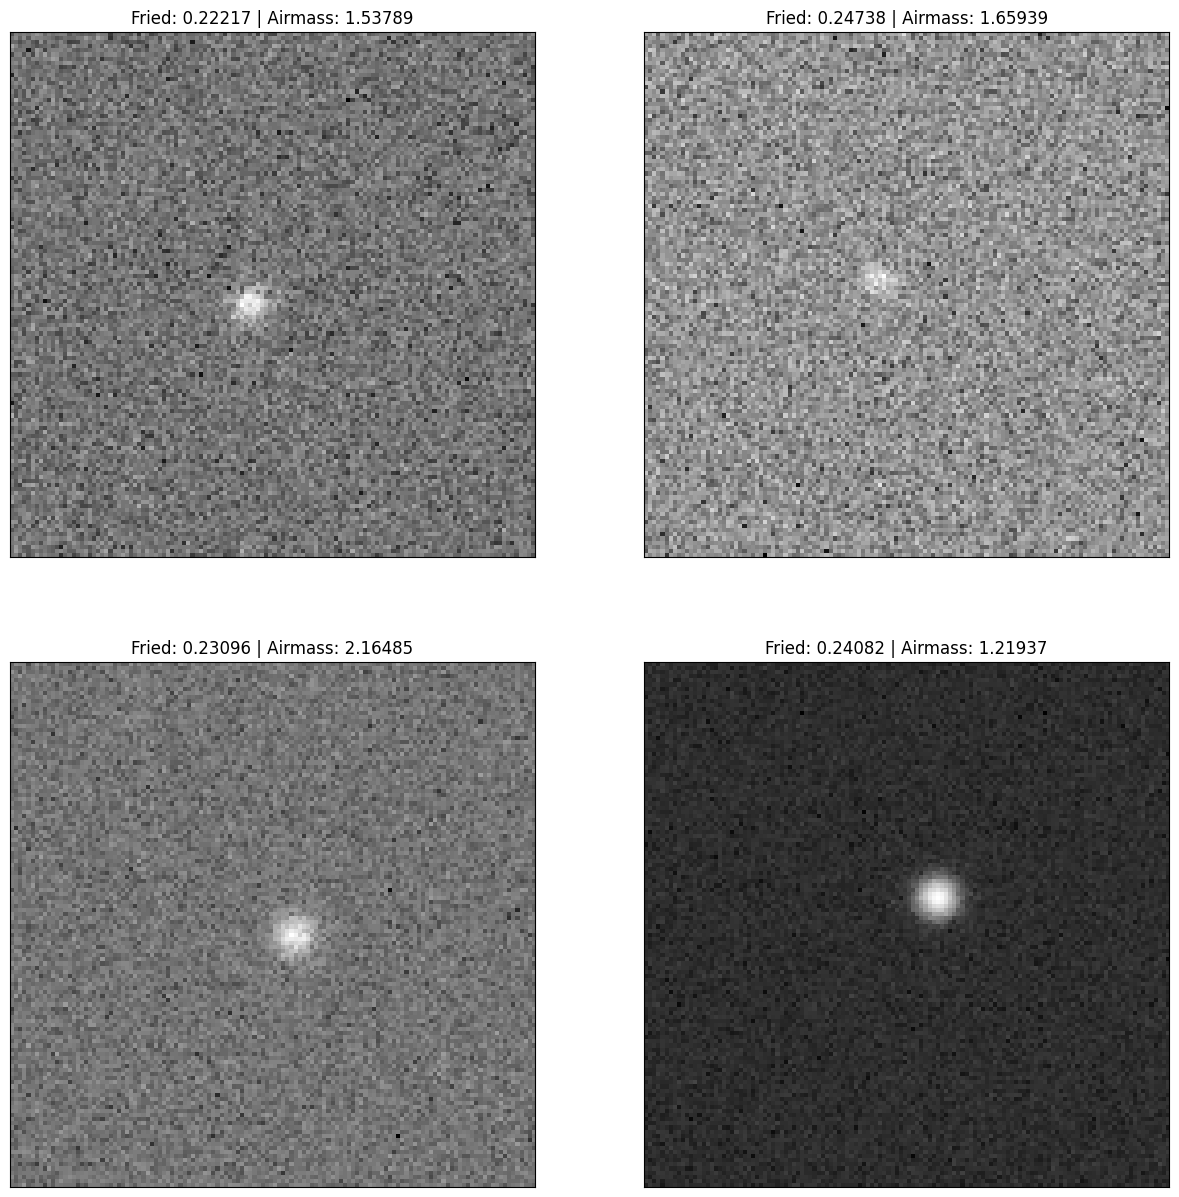

In [543]:
n_rows, n_cols = 2, 2

plt.figure(figsize=(15, 15))

for row in range(n_rows):
    for col in range(n_cols):
        idx = row * n_cols + col
        img = np.array(Image.open(f'/kaggle/input/datasets/abukanabek/practice-ceoai-2026-star-observatory-dataset/train_data/train_images/{train_df['image_id'][idx]}'))
        plt.subplot(n_rows, n_cols, idx+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Fried: {train_df['fried_parameter'][idx]:.5f} | Airmass: {train_df['airmass'][idx]:.5f}')
        plt.xticks([])
        plt.yticks([])

plt.show()

In [544]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_ds = AstralDataset(train_df, is_test=False, transform=transform)
valid_ds = AstralDataset(valid_df, is_test=False, transform=transform)
test_ds = AstralDataset(test_df, is_test=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

(13, 4, 19)

In [545]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([16, 1, 128, 128]), torch.Size([16])]

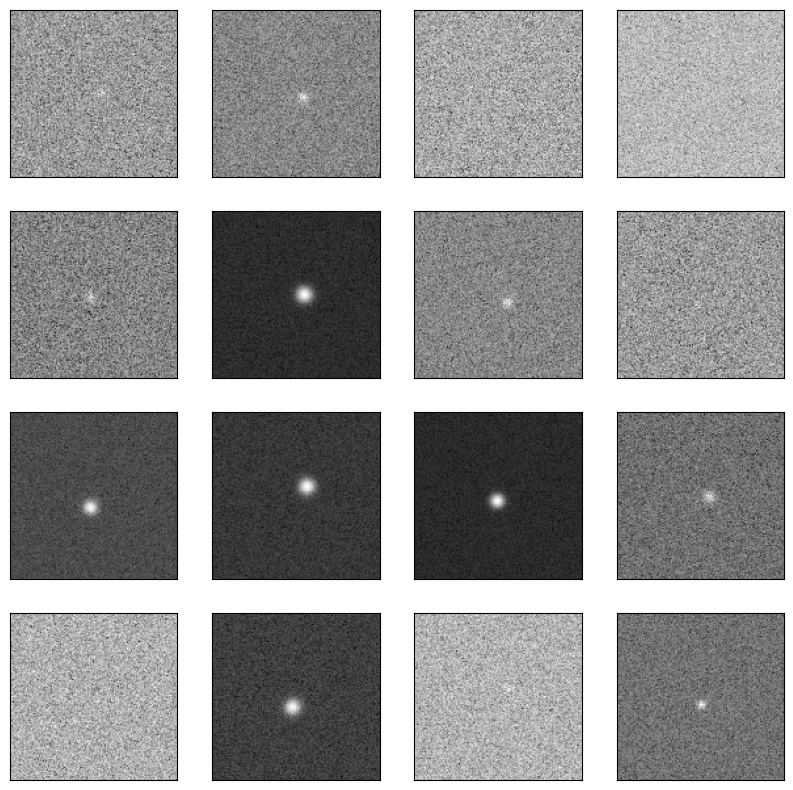

In [546]:
n_rows, n_cols = int(np.sqrt(batch_size)), int(np.sqrt(batch_size))

plt.figure(figsize=(10, 10))

for row in range(n_rows):
    for col in range(n_cols):
        sample_idx = row * n_cols + col
        sample_img = batch[0][sample_idx].permute(1, 2, 0).numpy()
        plt.subplot(n_rows, n_cols, sample_idx+1)
        plt.imshow(sample_img, cmap='gray')
        plt.xticks([])
        plt.yticks([])

plt.show()

In [547]:
from itertools import product

subtask1 = []
indices_arr = np.array(list(product(range(1, 128+1), range(1, 128+1))))

for batch in tqdm(test_loader):
    for img in batch:
        img_numpy = img.permute(1, 2, 0).numpy()
        # img_mask = (img_numpy >= (img_numpy.max()+img_numpy.min())*0.8)
        img_flat = img_numpy.reshape(-1, 1)
        contr = indices_arr * img_flat
        if img_flat.sum() <= 0:
            ans = np.array([64, 64])
        else:
            ans = np.clip(np.floor(contr.sum(axis=0) / img_flat.sum()), 1, 128)
        subtask1.append(np.array(list(map(int, ans))))

subtask1[:5]

  0%|          | 0/19 [00:00<?, ?it/s]

[array([64, 64]),
 array([64, 64]),
 array([64, 64]),
 array([64, 64]),
 array([64, 64])]

In [548]:
class AstralModel(nn.Module):
    def __init__(self, in_channels=1, out_features=1):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 4 64 64
            
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 16 32 32

            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 16 16

            nn.Flatten(),
            nn.Linear(64*16*16, 4096),
            nn.Dropout(0.2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(4096, 1),
        )
    def forward(self, x):
        return self.layers(x)

model = AstralModel().to(device)

In [549]:
epochs = 100
log_rate = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [550]:
for epoch in tqdm(range(epochs), desc='Epoch'):
    model.train()
    i, rloss = 0, 0
    for X, y in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        X, y = X.to(device), y.to(device)
        y = torch.exp(y)
        output = model(X).squeeze()
        output = torch.exp(output)
        loss = criterion(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        rloss += loss.item()
        i += 1
        cur_loss = np.sqrt(rloss/i)
        pbar.set_postfix({'loss': f'{cur_loss:.5f}'})
    if (epoch+1) % log_rate == 0:
        print(f'Epoch: {epoch+1}/{epochs} | Train Loss: {cur_loss:.5f}')

    model.eval()
    i, rloss = 0, 0
    for X, y in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        X, y = X.to(device), y.to(device)
        y = torch.exp(y)
        with torch.no_grad():
            output = model(X).squeeze()
            output = torch.exp(output)
            loss = criterion(output, y)

        rloss += loss.item()
        i += 1
        cur_loss = np.sqrt(rloss/i)
        pbar.set_postfix({'loss': f'{cur_loss:.5f}'})
    if (epoch+1) % log_rate == 0:
        print(f'Valid Loss: {cur_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.7f}')

    scheduler.step()

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/13 [00:00<?, ?it/s]

Valid Loader:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/13 [00:00<?, ?it/s]

Valid Loader:   0%|          | 0/4 [00:00<?, ?it/s]

...

Valid Loader:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch: 100/100 | Train Loss: 1715.62290


Valid Loader:   0%|          | 0/4 [00:00<?, ?it/s]

Valid Loss: 1805.95728 | LR: 0.0000000


In [551]:
subtask2 = []

model.eval()

for X in (pbar := tqdm(test_loader, desc='Test Loader', leave=True)):
    X = X.to(device)
    with torch.no_grad():
        output = model(X).squeeze()
        output = torch.exp(output)
    subtask2.extend(output.cpu().numpy().tolist())

subtask2 = np.array(subtask2)
subtask2[:5]

Test Loader:   0%|          | 0/19 [00:00<?, ?it/s]

array([12587.47265625,  1827.96337891,  1873.85070801,  2168.27539062,
        1665.36572266])

In [552]:
def build_subtask(sid, answers):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["image_id"],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, answers) for sid, answers in subtasks])
submission

,subtaskID,datapointID,answer
0,1,00000.png,"[64, 64]"
1,1,00001.png,"[64, 64]"
2,1,00002.png,"[64, 64]"
3,1,00003.png,"[64, 64]"
4,1,00004.png,"[64, 64]"
...,...,...,...
295,2,00295.png,5467.996582
296,2,00296.png,1587.914429
297,2,00297.png,1721.505371
298,2,00298.png,17437.984375


In [553]:
submission.to_csv("submission.csv", index=False)